Name:- Tanmay Santosh Sanap

Roll No:-40

Student Id:- 5144978

College:- B K BIRLA COLLEGE

Subject:-Data Engineering (Practical No :- 10)

##End-to-End Data EngineeringMini Project:-

This comprehensive, standalone mini-project fulfills the requirements of Practical 10.While originally designed for a group of two, this scope has been expanded and adaptedfor a single developer to showcase a complete Data Engineering lifecycle.

The project simulates a retail company's pipeline. It includes:

1.Data Ingestion:
Reading from diverse sources (CSV and JSON).

2.Data Cleaning & Transformation:
Handling missing values, standardizing dates, andcalculating derived metrics.

3.Data Warehouse Design:
Implementing a Star Schema (Fact and Dimension tables).

4.Storage:
Loading the transformed data into a relational SQLite database.

5.Reporting:
Querying the warehouse to generate a business report and a datavisualization.

     STARTING END-TO-END DATA ENGINEERING PIPELINE

[Phase 0] Generating simulated raw data...

[Phase 1] Extracting data from multiple sources...

Customers Data:
   customer_id first_name last_name region
0            1      Alice     Smith  North
1            2        Bob     Jones  South
2            3    Charlie     Brown   East
3            4      Diana    Prince   West
4            5        Eve       NaN  North

Products Data:
   product_id product_name     category   price
0         101       Laptop  Electronics  1200.0
1         102   Desk Chair    Furniture   150.5
2         103        Mouse  Electronics    25.0
3         104     Notebook   Stationery     5.0

Transactions Data:
   tx_id        date  customer_id  product_id  quantity
0   1001  2026-10-01            1         101         1
1   1002  2026-10-02            2         102         2
2   1003         NaN            3         103         1
3   1004  2026-10-02            1         103         2
4   1005  2026-10-03  

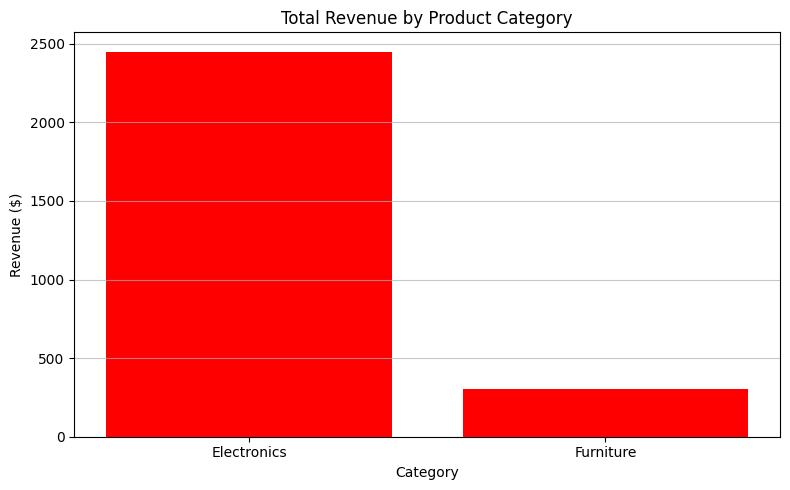


> Red revenue chart saved as 'revenue_report_chart.png'

Exporting Star Schema to CSV...
> Exported Star Schema to CSV for Power BI / Tableau.

Database Tables:
           name
0  dim_customer
1   dim_product
2      dim_date
3    fact_sales

       PIPELINE EXECUTION COMPLETE


In [3]:
# ============================================================
# PRACTICAL 10
# END-TO-END DATA ENGINEERING MINI PROJECT
# ============================================================

import pandas as pd
import sqlite3
import json
import os
import matplotlib.pyplot as plt


print("=" * 70)
print("     STARTING END-TO-END DATA ENGINEERING PIPELINE")
print("=" * 70)


# ============================================================
# PHASE 0: SETUP & RAW DATA GENERATION
# ============================================================

print("\n[Phase 0] Generating simulated raw data...")


# ------------------------------------------------------------
# 1. CUSTOMERS DATA - CSV
# ------------------------------------------------------------

customers_data = """customer_id,first_name,last_name,region
1,Alice,Smith,North
2,Bob,Jones,South
3,Charlie,Brown,East
4,Diana,Prince,West
5,Eve,,North"""

with open("raw_customers.csv", "w") as f:
    f.write(customers_data)


# ------------------------------------------------------------
# 2. PRODUCTS DATA - JSON
# ------------------------------------------------------------

products_data = [
    {
        "product_id": 101,
        "product_name": "Laptop",
        "category": "Electronics",
        "price": 1200.00
    },
    {
        "product_id": 102,
        "product_name": "Desk Chair",
        "category": "Furniture",
        "price": 150.50
    },
    {
        "product_id": 103,
        "product_name": "Mouse",
        "category": "Electronics",
        "price": 25.00
    },
    {
        "product_id": 104,
        "product_name": "Notebook",
        "category": "Stationery",
        "price": 5.00
    }
]

with open("raw_products.json", "w") as f:
    json.dump(products_data, f)


# ------------------------------------------------------------
# 3. TRANSACTIONS DATA - CSV
# ------------------------------------------------------------

transactions_data = """tx_id,date,customer_id,product_id,quantity
1001,2026-10-01,1,101,1
1002,2026-10-02,2,102,2
1003,,3,103,1
1004,2026-10-02,1,103,2
1005,2026-10-03,4,104,-5
1006,2026-10-04,5,101,1"""

with open("raw_transactions.csv", "w") as f:
    f.write(transactions_data)


# ============================================================
# PHASE 1: DATA INGESTION
# ============================================================

print("\n[Phase 1] Extracting data from multiple sources...")


# Read customer CSV
df_customers = pd.read_csv(
    "raw_customers.csv"
)


# Read products JSON
df_products = pd.read_json(
    "raw_products.json"
)


# Read transactions CSV
df_transactions = pd.read_csv(
    "raw_transactions.csv"
)


print("\nCustomers Data:")
print(df_customers)

print("\nProducts Data:")
print(df_products)

print("\nTransactions Data:")
print(df_transactions)


# ============================================================
# PHASE 2: DATA CLEANING & TRANSFORMATION
# ============================================================

print("\n[Phase 2] Cleaning and Transforming data...")


# ------------------------------------------------------------
# CLEAN CUSTOMERS
# ------------------------------------------------------------

# Fill missing last names
df_customers["last_name"] = (
    df_customers["last_name"]
    .fillna("Unknown")
)


# Create full name
df_customers["full_name"] = (
    df_customers["first_name"]
    + " "
    + df_customers["last_name"]
)


# Select required columns
df_customers = df_customers[
    [
        "customer_id",
        "full_name",
        "region"
    ]
]


# ------------------------------------------------------------
# CLEAN TRANSACTIONS
# ------------------------------------------------------------

initial_tx_count = len(df_transactions)


# Remove transactions with missing dates
df_transactions = df_transactions.dropna(
    subset=["date"]
)


# Remove negative or zero quantities
df_transactions = df_transactions[
    df_transactions["quantity"] > 0
]


# Display number of removed records
print(
    f"> Dropped "
    f"{initial_tx_count - len(df_transactions)} "
    f"invalid transaction records."
)


# ------------------------------------------------------------
# DATE TRANSFORMATION
# ------------------------------------------------------------

df_transactions["date"] = pd.to_datetime(
    df_transactions["date"]
)


# ============================================================
# CREATE DATE DIMENSION
# ============================================================

df_date_dim = pd.DataFrame({

    "date_id":
        df_transactions["date"]
        .dt.strftime("%Y%m%d")
        .astype(int),

    "full_date":
        df_transactions["date"].dt.date,

    "year":
        df_transactions["date"].dt.year,

    "month":
        df_transactions["date"].dt.month,

    "day":
        df_transactions["date"].dt.day
})


# Remove duplicate dates
df_date_dim = df_date_dim.drop_duplicates()


# ------------------------------------------------------------
# CREATE date_id IN TRANSACTIONS
# ------------------------------------------------------------

df_transactions["date_id"] = (
    df_transactions["date"]
    .dt.strftime("%Y%m%d")
    .astype(int)
)


# ------------------------------------------------------------
# JOIN TRANSACTIONS WITH PRODUCTS
# ------------------------------------------------------------

df_transactions = df_transactions.merge(
    df_products[
        [
            "product_id",
            "price"
        ]
    ],
    on="product_id",
    how="left"
)


# ------------------------------------------------------------
# CALCULATE TOTAL AMOUNT
# ------------------------------------------------------------

df_transactions["total_amount"] = (
    df_transactions["quantity"]
    *
    df_transactions["price"]
)


# ------------------------------------------------------------
# CREATE FACT TABLE
# ------------------------------------------------------------

df_fact_sales = df_transactions[
    [
        "tx_id",
        "date_id",
        "customer_id",
        "product_id",
        "quantity",
        "total_amount"
    ]
]


print("\nCleaned Customer Data:")
print(df_customers)

print("\nDate Dimension:")
print(df_date_dim)

print("\nFact Sales:")
print(df_fact_sales)


# ============================================================
# PHASE 3: DATA WAREHOUSE DESIGN & STORAGE
# ============================================================

print(
    "\n[Phase 3] Loading Star Schema "
    "into SQLite Data Warehouse..."
)


db_name = "enterprise_data_warehouse.db"


# Create SQLite connection
conn = sqlite3.connect(
    db_name
)


# ------------------------------------------------------------
# LOAD CUSTOMER DIMENSION
# ------------------------------------------------------------

df_customers.to_sql(
    "dim_customer",
    conn,
    if_exists="replace",
    index=False
)


# ------------------------------------------------------------
# LOAD PRODUCT DIMENSION
# ------------------------------------------------------------

df_products.to_sql(
    "dim_product",
    conn,
    if_exists="replace",
    index=False
)


# ------------------------------------------------------------
# LOAD DATE DIMENSION
# ------------------------------------------------------------

df_date_dim.to_sql(
    "dim_date",
    conn,
    if_exists="replace",
    index=False
)


# ------------------------------------------------------------
# LOAD FACT TABLE
# ------------------------------------------------------------

df_fact_sales.to_sql(
    "fact_sales",
    conn,
    if_exists="replace",
    index=False
)


print(
    f"> Successfully loaded "
    f"{len(df_fact_sales)} "
    f"records into fact_sales."
)


# ============================================================
# PHASE 4: REPORTING & VISUALIZATION
# ============================================================

print(
    "\n[Phase 4] Generating Business Reports "
    "from Data Warehouse..."
)


# ============================================================
# REPORT 1: REVENUE BY CATEGORY
# ============================================================

query_sales_by_category = """
SELECT
    p.category,
    SUM(f.quantity) AS items_sold,
    SUM(f.total_amount) AS total_revenue

FROM fact_sales f

JOIN dim_product p
    ON f.product_id = p.product_id

GROUP BY p.category

ORDER BY total_revenue DESC
"""


df_report1 = pd.read_sql(
    query_sales_by_category,
    conn
)


print(
    "\n--- REPORT 1: Revenue by Category ---"
)

print(
    df_report1.to_string(
        index=False
    )
)


# ============================================================
# REPORT 2: TOP CUSTOMERS
# ============================================================

query_top_customers = """
SELECT
    c.full_name,
    c.region,
    SUM(f.total_amount) AS lifetime_value

FROM fact_sales f

JOIN dim_customer c
    ON f.customer_id = c.customer_id

GROUP BY
    c.full_name,
    c.region

ORDER BY lifetime_value DESC
"""


df_report2 = pd.read_sql(
    query_top_customers,
    conn
)


print(
    "\n--- REPORT 2: Top Customers ---"
)

print(
    df_report2.to_string(
        index=False
    )
)


# ============================================================
# RED REVENUE CHART
# ============================================================

print(
    "\nCreating Revenue Visualization..."
)


plt.figure(
    figsize=(8, 5)
)


# RED BARS
plt.bar(
    df_report1["category"],
    df_report1["total_revenue"],
    color="red"
)


plt.title(
    "Total Revenue by Product Category"
)

plt.xlabel(
    "Category"
)

plt.ylabel(
    "Revenue ($)"
)


plt.grid(
    axis="y",
    linestyle="-",
    alpha=0.7
)


plt.tight_layout()


# Save chart
chart_filename = "revenue_report_chart.png"


plt.savefig(
    chart_filename
)


# Display chart
plt.show()


print(
    f"\n> Red revenue chart saved as "
    f"'{chart_filename}'"
)


# ============================================================
# EXPORT STAR SCHEMA TO CSV
# ============================================================

print(
    "\nExporting Star Schema to CSV..."
)


df_fact_sales.to_csv(
    "fact_sales.csv",
    index=False
)


df_customers.to_csv(
    "dim_customer.csv",
    index=False
)


df_products.to_csv(
    "dim_product.csv",
    index=False
)


df_date_dim.to_csv(
    "dim_date.csv",
    index=False
)


print(
    "> Exported Star Schema to CSV "
    "for Power BI / Tableau."
)


# ============================================================
# SHOW DATABASE TABLES
# ============================================================

print("\nDatabase Tables:")


tables = pd.read_sql(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table'
    """,
    conn
)


print(tables)


# ============================================================
# CLOSE DATABASE
# ============================================================

conn.close()


# ============================================================
# CLEANUP RAW INPUT FILES
# ============================================================

if os.path.exists("raw_customers.csv"):
    os.remove("raw_customers.csv")

if os.path.exists("raw_products.json"):
    os.remove("raw_products.json")

if os.path.exists("raw_transactions.csv"):
    os.remove("raw_transactions.csv")


# ============================================================
# FINAL MESSAGE
# ============================================================

print("\n" + "=" * 70)

print(
    "       PIPELINE EXECUTION COMPLETE"
)

print("=" * 70)